# Linear Regression

Linear regression is a statistical method that models the relationship between one or more input variables (also called *features*) and a continuous output variable (also called *target*). The goal is to **fit** a line (or hyperplane in higher dimensions) that best represents the data.

## The Analogy

Imagine predicting the **price** of a house based on a single feature, say the **size** of the house (in square feet). If you plot this data, you will get a scatter plot. Your goal is to find the line that best fits this scatter of points. This line will allow you to predict the price for any given house size.

## The Linear Regression Equation

The equation of a simple linear regression model with one feature $x_1$ and one target $y$ is given by:

$$y = \theta_0 + \theta_1 x_1$$


Where:

- $y$ is the predicted target value (e.g., price, salary, etc.).
- $\theta_0$ is the *intercept* (also called the *bias*), representing the predicted value of $y$ when $x_1$ = 0.
- $\theta_1$ is the *slope* (or weight) that represents the relationship between $x_1$ and $y$.
- $x_1$ is the input feature (e.g., house size).


$$\theta_1 = \frac{\sum_{i=1}^{m}(x_{1i} - \bar{x}_1)(y_i - \bar{y})}{\sum_{i=1}^{m}(x_{1i} - \bar{x}_1)^2}$$


Where:
- $x_{1i}$ is the value of the $i^{th}$ sample.
- $y_i$ is the value of the $i^{th}$ target.
- $\bar{x}_1$ and $\bar{y}$ are the means of the feature and target, respectively.

Once we have $\theta_1$, the intercept $(\theta_0)$ can be found using:

$$\theta_0 = \bar{y} - \theta_1 \bar{x}_1$$

Where $\bar{x}_1$ and $\bar{y}$ are the mean values of $x_1$ and $y$.


## Bias and Intercept

The **intercept** ($\theta_0$) represents the value of $y$ when $x_1$ = 0. In the house pricing analogy, it might represent the price of a house when the size is zero (which doesn’t make practical sense, but is mathematically required).

The **slope** $\theta_1$ shows how $y$ changes with respect to $x_1$. If $\theta_1$  > 0, as $x_1$ increases, $y$ increases; if $\theta_1$ < 0, $y$ decreases as $x_1$ increases.

## The Cost Function: Mean Squared Error (MSE)

To fit the line, we need to minimize the difference between the actual values $y$ and the predicted values $\hat{y}$. The cost function (Mean Squared Error, MSE) is given by:


$$J(\theta_0, \theta_1) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$


Where:
- $m$ is the number of data points.
- $\hat{y}_i = \theta_0 + \theta_1 x_1$ is the predicted value for the $i^{th}$ data point.
- $y_i$ is the actual value for the $i^{th}$ data point.

The goal is to find $\theta_0$ and $\theta_1$ that minimize this cost function.

## Multiple Linear Regression

When we have more than one feature, the equation generalizes to:

$y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$

Where:
- $x_1, x_2, \dots, x_n$ are the input features.
- $\theta_1, \theta_2, \dots, \theta_n$ are the corresponding weights for each feature.

This general equation is used when we have multiple attributes (e.g., house size, number of rooms, location) to predict a target variable (house price).


## Gradient Descent vs Normal Equation
- The **Normal Equation** can be solved directly by inverting the matrix $X^T X$, but it becomes computationally expensive for large datasets.
- **Gradient Descent** is an iterative optimization technique that works well with large datasets, especially when the number of features is high.

## Conclusion

In this lab, we’ll simulate a simple linear regression problem and use the Normal Equation to compute the optimal $\theta_0$ and $\theta_1$. We’ll also extend this to multiple linear regression and explore the effect of adding more features.

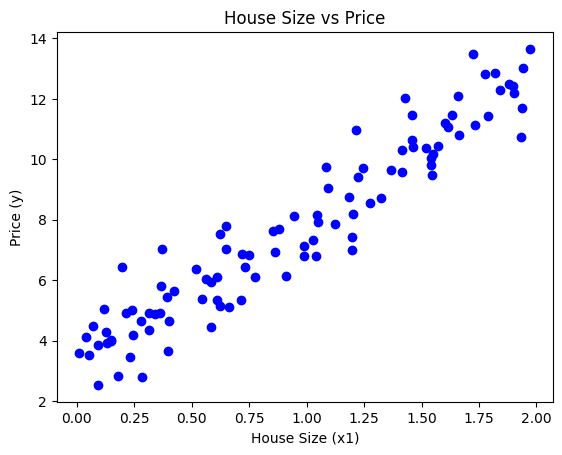

In [ ]:
#1) Simulate a Dataset for Simple Linear Regression

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) # Ensures that the random numbers generated are the same every time you run the code

# Generate data: x1 is the feature (e.g., house size), y is the target (e.g., price)
m = 100  # number of data points
x1 = 2 * np.random.rand(m, 1)  # feature: house size (e.g., between 0 and 2)
theta_0 = 3  # intercept (bias)
theta_1 = 5  # slope (weight)
y = theta_0 + theta_1 * x1 + np.random.randn(m, 1)  # add noise to simulate real-world unpredictability.

# Visualize the data
plt.scatter(x1, y, color='blue', label='Data points')
plt.xlabel('House Size (x1)')
plt.ylabel('Price (y)')
plt.title('House Size vs Price')
plt.show()

In [ ]:
# 2) Implementing Linear Regression with Normal Equation

# Step 1: Calculate the means of x1 and y
x1_mean = np.mean(x1)
y_mean = np.mean(y)

# Step 2: Calculate the slope (theta_1)
numerator = np.sum((x1 - x1_mean) * (y - y_mean))
denominator = np.sum((x1 - x1_mean) ** 2)
theta_1_manual = numerator / denominator

# Step 3: Calculate the intercept (theta_0)
theta_0_manual = y_mean - (theta_1_manual * x1_mean)

# Print the results
print(f"Calculated theta_0 (Intercept): {theta_0_manual}")
print(f"Calculated theta_1 (Slope): {theta_1_manual}")

Calculated theta_0 (Intercept): 3.215096157546749
Calculated theta_1 (Slope): 4.770113386438484


$$\hat{y} = \theta_0 + \theta_1 x_1$$ make predictions


In [ ]:
# Step 4: Predicting for a new test case (e.g., x1 = 1.5)
x1_test = 1.5  # New feature value (house size)
y_pred = theta_0_manual + theta_1_manual * x1_test

print(f"Predicted value of y for x1 = {x1_test}: {y_pred}")

Predicted value of y for x1 = 1.5: 10.370266237204476


#  Multiple Linear Regression with $x_1, x_2, x_3$

In [ ]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate multiple features
x1 = 2 * np.random.rand(100, 1)   # Feature 1
x2 = 3 * np.random.rand(100, 1)   # Feature 2
x3 = 2 * np.random.rand(100, 1)   # Feature 3

# Create feature matrix with intercept term
X_multi = np.c_[np.ones((100, 1)), x1, x2, x3]

# True theta values
theta_multi_true = np.array([[3], [5], [1], [-2]])

# Generate target variable with noise
y_multi = X_multi.dot(theta_multi_true) + np.random.randn(100, 1)

# ==============================
# NORMAL EQUATION SOLUTION
# ==============================

# Step 1: Compute X^T X
XT_X = X_multi.T.dot(X_multi)

# Step 2: Compute (X^T X)^(-1)
XT_X_inv = np.linalg.inv(XT_X)

# Step 3: Compute X^T y
XT_y = X_multi.T.dot(y_multi)

# Step 4: Compute theta
theta_estimated = XT_X_inv.dot(XT_y)

# Print results
print("True Theta Values:")
print(theta_multi_true)

print("\nEstimated Theta Values (Normal Equation):")
print(theta_estimated)

True Theta Values:
[[ 3]
 [ 5]
 [ 1]
 [-2]]

Estimated Theta Values (Normal Equation):
[[ 2.59997212]
 [ 5.20796463]
 [ 1.06951657]
 [-1.83532591]]


In [ ]:
# Step 5: Predicting for a new test case with multiple features
X_test_multi = np.array([1, 1.5, 2.0, 0.8])  # [intercept, x1, x2, x3]
y_pred_manual = X_test_multi.dot([theta_0_manual, theta_1_manual, theta_2_manual, theta_3_manual])

print(f"Predicted value of y for the new test case with multiple features: {y_pred_manual}")

Predicted value of y for the new test case with multiple features: 17.431195482559417


# **Tutorials/Resources**

[Machine Learning Specialization by Andrew Ng](https://www.youtube.com/watch?v=vStJoetOxJg&list=PLkDaE6sCZn6FNC6YRfRQc_FbeQrF8BwGI)

[Linear Regression in 3 minutes](https://www.youtube.com/watch?v=3dhcmeOTZ_Q&t=35s)